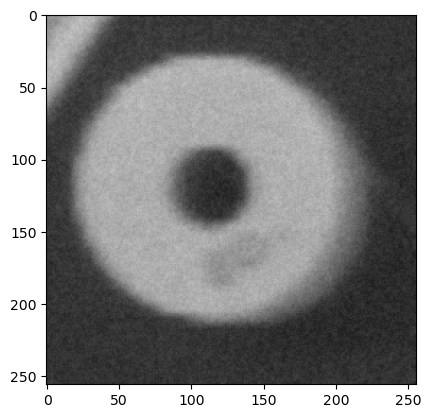

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/rondelle.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()


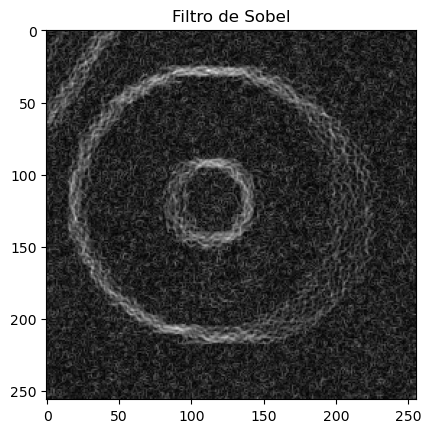

0.0 0.1474667544754051


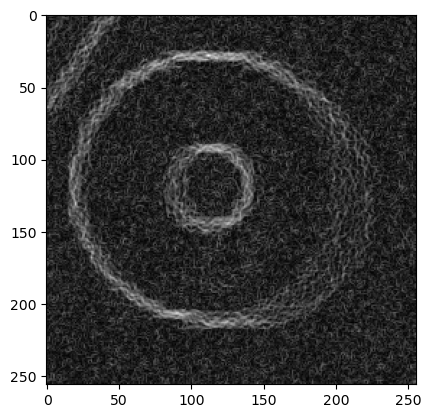

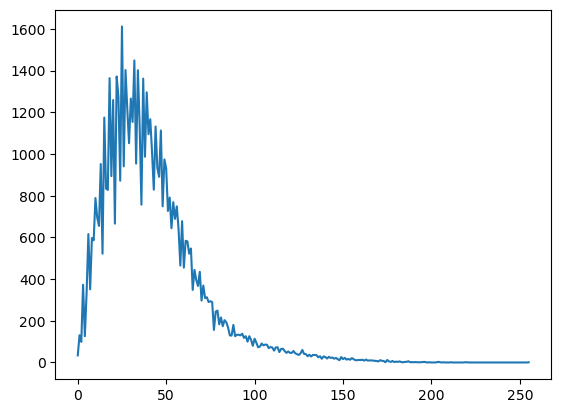

In [11]:
#Cargue y visualice la imagen rondelle.png. Aplique el operador de Sobel y describa el resultado (puede efectuar una calibración del histograma de la imagen obtenida para visualizar mejor el resultado).

from skimage.filters import sobel_h, sobel_v, sobel
from skimage import exposure

#Calcula bordes usando el filtro de sobel
img_s = sobel(image)
# Visualizar imagen
plt.imshow(img_s, cmap="gray")
plt.title("Filtro de Sobel")
plt.show()

print(img_s.min(), img_s.max())
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_s, in_range=(img_s.min(),img_s.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

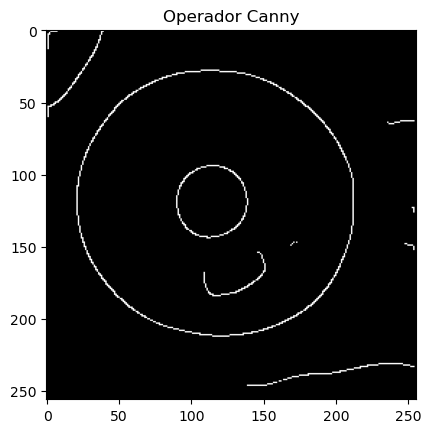

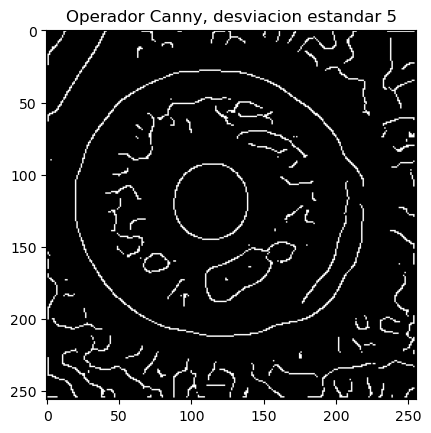

In [21]:
#Ahora aplique sobre la imagen original el operador de Canny, con los siguientes valores de parámetros y visualice la imagen resultado y descríbala:

from skimage.feature import canny

sigma=10 #desviacion estandar
low_threshold=0
high_threshold=1

edges2 = canny(image, sigma=sigma, low_threshold=low_threshold, high_threshold=high_threshold)

# Visualizar imagen
plt.imshow(edges2, cmap="gray")
plt.title("Operador Canny")
plt.show()

#Disminuya la desviación a estándar a 5 (en X y en Y ), visualice la imagen resultado y explique lo que sucede.
sigma=5 #desviacion estandar
edges2 = canny(image, sigma=sigma, low_threshold=low_threshold, high_threshold=high_threshold)

# Visualizar imagen
plt.imshow(edges2, cmap="gray")
plt.title("Operador Canny, desviacion estandar 5")
plt.show()

explique lo que sucede

A medida que el valor de sigma (desviacion estandar) es menor, entonces se conservará el nivel de detalle, detectando bordes muy finos de los objetos de la imagen, pero esto conlleva a que el ruido sea detectado y nos genere artefactos. A medida que el valor de sigma aumenta, tendremos mas suavizado, perdemos nivel de detalle pero obtendremos bordes mas gruesos y podremos eliminar esos bordes muy finos (que el ruido los genera normalmente) y nos quedamos con los objetos grandes y de bordes gruesos



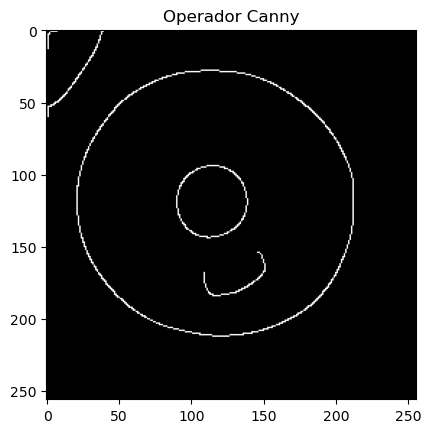

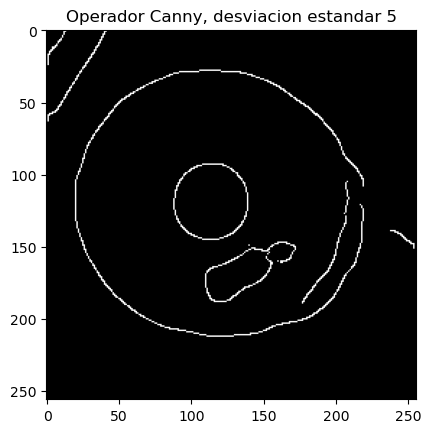

In [22]:
#Aumente el umbral superior a 5 con los valores de desviación estándar del punto 3 y 4. visualice y compare los resultados con las imágenes obtenidas en el punto anterior.

sigma=10 #desviacion estandar
low_threshold=0
high_threshold=5

edges2 = canny(image, sigma=sigma, low_threshold=low_threshold, high_threshold=high_threshold)

# Visualizar imagen
plt.imshow(edges2, cmap="gray")
plt.title("Operador Canny")
plt.show()

#Disminuya la desviación a estándar a 5 (en X y en Y ), visualice la imagen resultado y explique lo que sucede.
sigma=5 #desviacion estandar
edges2 = canny(image, sigma=sigma, low_threshold=low_threshold, high_threshold=high_threshold)

# Visualizar imagen
plt.imshow(edges2, cmap="gray")
plt.title("Operador Canny, desviacion estandar 5")
plt.show()

compare los resultados con las imágenes obtenidas en el punto anterior.

Al aumentar el umbral superior a 5, tanto con sigma=10 como con sigma=5, se observa que la cantidad de bordes detectados disminuye notablemente en comparación con los resultados anteriores (donde el umbral superior era 1). Ahora, solo se conservan los contornos más fuertes y definidos, mientras que los bordes débiles y el ruido desaparecen casi por completo.
 
En resumen, un umbral superior más alto hace que el operador de Canny sea más selectivo, mostrando únicamente los bordes más marcados y eliminando detalles y bordes tenues, independientemente del valor de sigma utilizado.